<a href="https://colab.research.google.com/github/Slautin/2026_photoKPFM/blob/main/1_photoKPFM_PEA-FAPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# photoKPFM experiment


System: PEA-FABI



**B. Slautin, J. Marshall, M. Ahmadi, S. Kalinin**

In [ ]:
!pip install aespm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.9/208.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.0/161.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you 

In [ ]:
!pip install botorch

  Using cached botorch-0.18.1-py3-none-any.whl.metadata (10 kB)
  Using cached pyre_extensions-0.0.32-py3-none-any.whl.metadata (4.0 kB)
  Using cached gpytorch-1.15.2-py3-none-any.whl.metadata (8.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import json

import aespm.tools as at

In [ ]:
#experimental data 1
!gdown https://drive.google.com/file/d/1Mkq79izmMxxRkxl0JruYeQxtEbfzKtfP/view?usp=sharing --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1Mkq79izmMxxRkxl0JruYeQxtEbfzKtfP
To: /content/PEA_FAPI_2.zip
100% 9.08M/9.08M [00:00<00:00, 103MB/s]


In [ ]:
!unzip PEA_FAPI_2

Archive:  PEA_FAPI_2.zip
 extracting: PEA_FAPI_2/20260119_PEA_FAPI_2_0.gif  
 extracting: PEA_FAPI_2/20260119_PEA_FAPI_2_0.h5  
 extracting: PEA_FAPI_2/20260119_PEA_FAPI_2_1.gif  
 extracting: PEA_FAPI_2/20260119_PEA_FAPI_2_1.h5  
 extracting: PEA_FAPI_2/SKPM_0001.ibw  
 extracting: PEA_FAPI_2/SKPM_0002.ibw  
 extracting: PEA_FAPI_2/SKPM_0003.ibw  
 extracting: PEA_FAPI_2/SKPM_0004.ibw  
 extracting: PEA_FAPI_2/SKPM_0005.ibw  
 extracting: PEA_FAPI_2/SKPM_0006.ibw  
 extracting: PEA_FAPI_2/SKPM_0007.ibw  
 extracting: PEA_FAPI_2/SKPM_0008.ibw  
 extracting: PEA_FAPI_2/SKPM_0009.ibw  
 extracting: PEA_FAPI_2/SKPM_0010.ibw  
 extracting: PEA_FAPI_2/SKPM_0011.ibw  
 extracting: PEA_FAPI_2/SKPM_0012.ibw  
 extracting: PEA_FAPI_2/SKPM_0013.ibw  
 extracting: PEA_FAPI_2/SKPM_0014.ibw  
 extracting: PEA_FAPI_2/SKPM_0015.ibw  
 extracting: PEA_FAPI_2/SKPM_0016.ibw  
 extracting: PEA_FAPI_2/SKPM_0017.ibw  
 extracting: PEA_FAPI_2/SKPM_0018.ibw  
 extracting: PEA_FAPI_2/SKPM_0019.ibw  
 extracti

In [ ]:
#@title h5 load
def save_dict_to_hdf5(file_path, data_dict):
    with h5py.File(file_path, 'w') as f:
        _recursively_save(f, data_dict)

def _recursively_save(group, data):
    if isinstance(data, dict):
        for key, value in data.items():
            subgroup = group.create_group(str(key))
            _recursively_save(subgroup, value)

    elif isinstance(data, list):
        # Turn list into group with numerical keys
        for i, item in enumerate(data):
            subgroup = group.create_group(str(i))
            _recursively_save(subgroup, item)

    elif isinstance(data, np.ndarray):
        if data.dtype == object:
            # convert each element to string (json)
            data_as_str = np.array([json.dumps(x) for x in data], dtype='S256')
            group.create_dataset('value', data=data_as_str)
        else:
            group.create_dataset('value', data=data)

    elif isinstance(data, (int, float, np.int_, np.float_)):
        group.create_dataset('value', data=data)

    elif data is None:
        group.attrs['value'] = 'None'

    else:
        # Fallback: convert unknown object to JSON string
        group.create_dataset('value', data=json.dumps(data))


def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)



def _load_item(obj):
    """
    Load any HDF5 object (Group or Dataset) and reconstruct Python object.
    """
    # ---------------------------------------------------------
    # CASE 1 — HDF5 GROUP  (recursive dict or list)
    # ---------------------------------------------------------
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())

        # Empty group → return None or empty dict
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}

        # Detect list: all keys are integers
        if all(k.isdigit() for k in keys):
            lst = []
            for k in sorted(keys, key=lambda x: int(x)):
                lst.append(_load_item(obj[k]))
            return lst

        # Regular dictionary
        out = {}
        for k in keys:
            out[k] = _load_item(obj[k])

        # Special case: group representing None
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None

        return out

    # ---------------------------------------------------------
    # CASE 2 — HDF5 DATASET  (arrays / scalars / strings)
    # ---------------------------------------------------------
    elif isinstance(obj, h5py.Dataset):
        data = obj[()]

        # Scalar
        if np.isscalar(data):
            return data

        # Byte strings → JSON or text
        if isinstance(data, (bytes, np.bytes_)):
            try:
                return json.loads(data.decode())
            except:
                return data.decode()

        # Array of byte strings
        if data.dtype.kind == "S":
            try:
                return [json.loads(x.decode()) for x in data]
            except:
                return [x.decode() for x in data]

        # Normal numpy array
        return data

    # ---------------------------------------------------------
    # CASE 3 — Attributes marking None
    # ---------------------------------------------------------
    else:
        raise ValueError("Unknown HDF5 object type:", obj)


def get_arr(runs, key):
    """
    Extract numpy array from runs[key], automatically handling nested {'value': array}.
    """
    val = runs[key]
    if isinstance(val, dict) and "value" in val:
        return np.asarray(val["value"])
    return np.asarray(val)



In [ ]:
#@title gp model
from botorch.models import SingleTaskGP
from gpytorch.kernels import ScaleKernel, RBFKernel, MaternKernel
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
import torch
import gpytorch

def make_gp_model(X_train, y_train, interval = (0.01, 0.2)):
    # Convert numpy → torch
    if isinstance(X_train, np.ndarray):
        X_train = torch.tensor(X_train, dtype=torch.double)
    if isinstance(y_train, np.ndarray):
        y_train = torch.tensor(y_train, dtype=torch.double).unsqueeze(-1)

    N = X_train.shape[1]

    # ---- Kernel with ARD + bounds ----
    base_kernel = gpytorch.kernels.RBFKernel(ard_num_dims=N)
    base_kernel.lengthscale = 0.1 * torch.ones(N)  # good initialization
    base_kernel.raw_lengthscale_constraint = gpytorch.constraints.Interval(interval[0], interval[1])

    covar_module = gpytorch.kernels.ScaleKernel(base_kernel)
    covar_module.outputscale = 1.0
    covar_module.raw_outputscale_constraint = gpytorch.constraints.Interval(0.05, 5.0)

    # ---- Build GP ----
    gp = SingleTaskGP(X_train, y_train, covar_module=covar_module)

    # ---- Add noise prior (critically important) ----
    gp.likelihood.noise = torch.tensor(0.01)
    gp.likelihood.raw_noise_constraint = gpytorch.constraints.GreaterThan(1e-4)

    # ---- Fit GP ----
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)

    try:
        fit_gpytorch_mll(mll)
    except Exception:
        print("⚠ GP fitting failed — retrying with higher noise")
        gp.likelihood.noise = torch.tensor(0.05)
        fit_gpytorch_mll(mll)

    # Extract per-dimension lengthscales
    kl = gp.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()

    return gp, kl

In [ ]:
file_h5 = r"/content/PEA_FAPI_2/20260119_PEA_FAPI_2_0.h5"

In [ ]:
#load results
res_dict = load_hdf5_to_dict(file_h5)

In [ ]:
res_dict.keys()

dict_keys(['X', 'X_train', 'coord_array', 'dark_data', 'dark_fn', 'idx', 'light_data', 'light_fn', 'y_train'])

In [ ]:
print('Measured droplets number (0-95): ', res_dict['idx'])

Measured droplets number (0-95):  [ 1 53 25 87 70 39 13 95 62 79 32 46  7]


In [ ]:
dark_files = res_dict['dark_fn']
light_files = res_dict['light_fn']

X_train = res_dict['X_train']
X_train_int = (X_train*95).astype(int)
y_train = res_dict['y_train']
X = res_dict['X']

dark_data = res_dict['dark_data']
light_data = res_dict['light_data']
light_files = res_dict['light_fn']
idx = res_dict['idx']

In [ ]:
gp, kl = make_gp_model(X_train, y_train, interval=(0.01, 1))

In [ ]:
posterior = gp.posterior(torch.tensor(X))

mean = posterior.mean.detach().numpy().ravel()
std = posterior.variance.sqrt().detach().numpy().ravel()

Text(0.5, 1.0, '(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

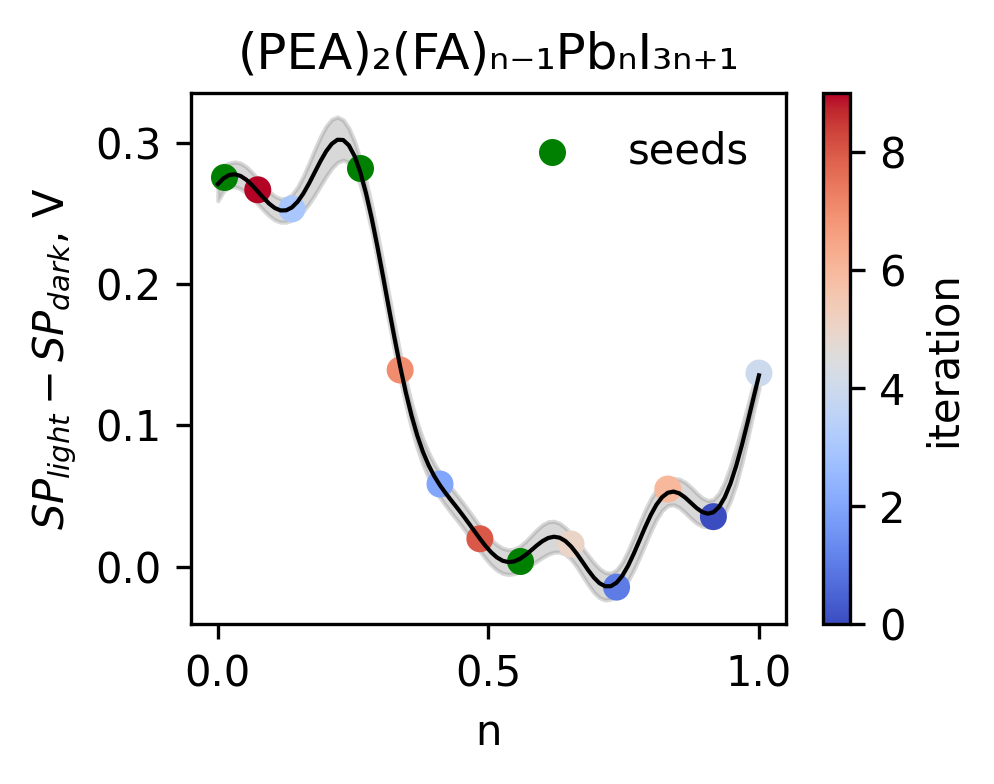

In [ ]:
fig = plt.figure(figsize=(3.2, 2.3), dpi=300)


plt.plot(X, mean, c='k', lw=1)
plt.fill_between(X.flatten(), mean-std, mean+std, alpha=0.3, color='gray')
plt.scatter(X_train.flatten()[:3], y_train[:3], s=30, color='green', label='seeds')
im = plt.scatter(X_train.flatten()[3:], y_train[3:], s=30, c=np.arange(len(y_train[3:])), cmap='coolwarm')
plt.colorbar(label='iteration')

plt.xlabel('n')
plt.ylabel('$SP_{light}-SP_{dark}$, V')
plt.legend(frameon=False)

plt.title('(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

In [ ]:
y_train_cr = light_data[:,10:-10,10:-10].mean((1,2)) - dark_data[:,10:-10,10:-10].mean((1,2))

In [ ]:
gp, kl = make_gp_model(X_train, y_train_cr, interval=(0.01, 1))

In [ ]:
posterior = gp.posterior(torch.tensor(X))

mean = posterior.mean.detach().numpy().ravel()
std = posterior.variance.sqrt().detach().numpy().ravel()

Text(0.5, 1.0, '(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

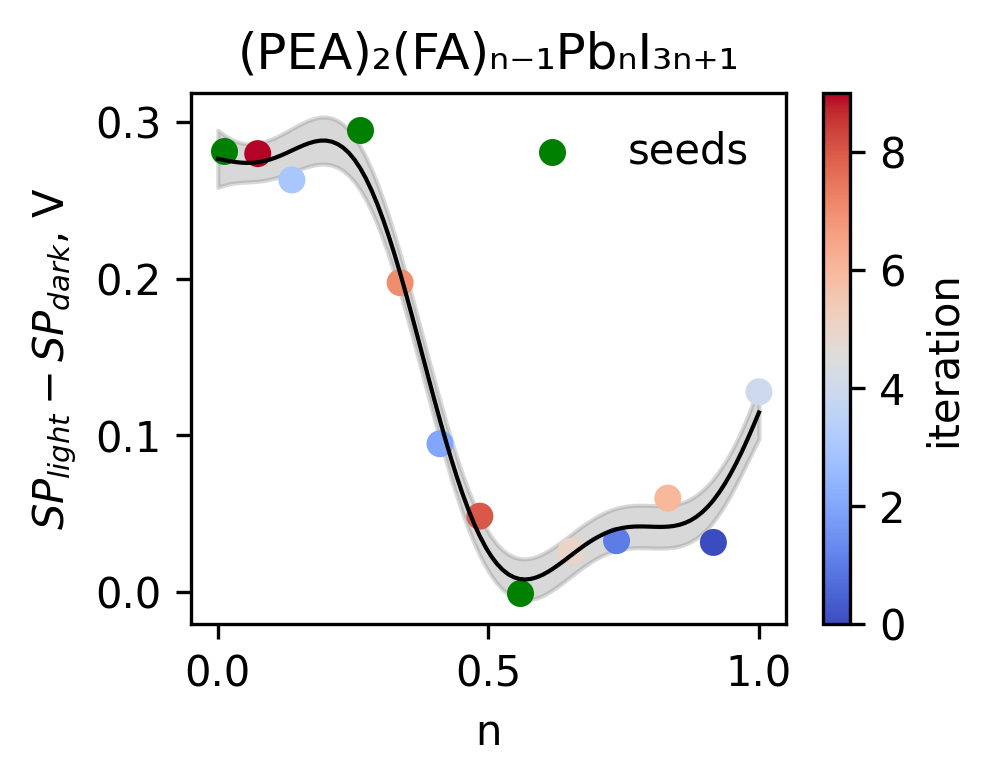

In [ ]:
fig = plt.figure(figsize=(3.2, 2.3), dpi=300)


plt.plot(X, mean, c='k', lw=1)
plt.fill_between(X.flatten(), mean-std, mean+std, alpha=0.3, color='gray')
plt.scatter(X_train.flatten()[:3], y_train_cr[:3], s=30, color='green', label='seeds')
im = plt.scatter(X_train.flatten()[3:], y_train_cr[3:], s=30, c=np.arange(len(y_train[3:])), cmap='coolwarm')
plt.colorbar(label='iteration')

plt.xlabel('n')
plt.ylabel('$SP_{light}-SP_{dark}$, V')
plt.legend(frameon=False)

plt.title('(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

In [ ]:
#SP_dark
sp_dark = dark_data[:,10:-10,10:-10].mean((1,2))
gp, kl = make_gp_model(X_train, sp_dark, interval=(0.01, 1))


In [ ]:
posterior = gp.posterior(torch.tensor(X))

mean = posterior.mean.detach().numpy().ravel()
std = posterior.variance.sqrt().detach().numpy().ravel()

Text(0.5, 1.0, '(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

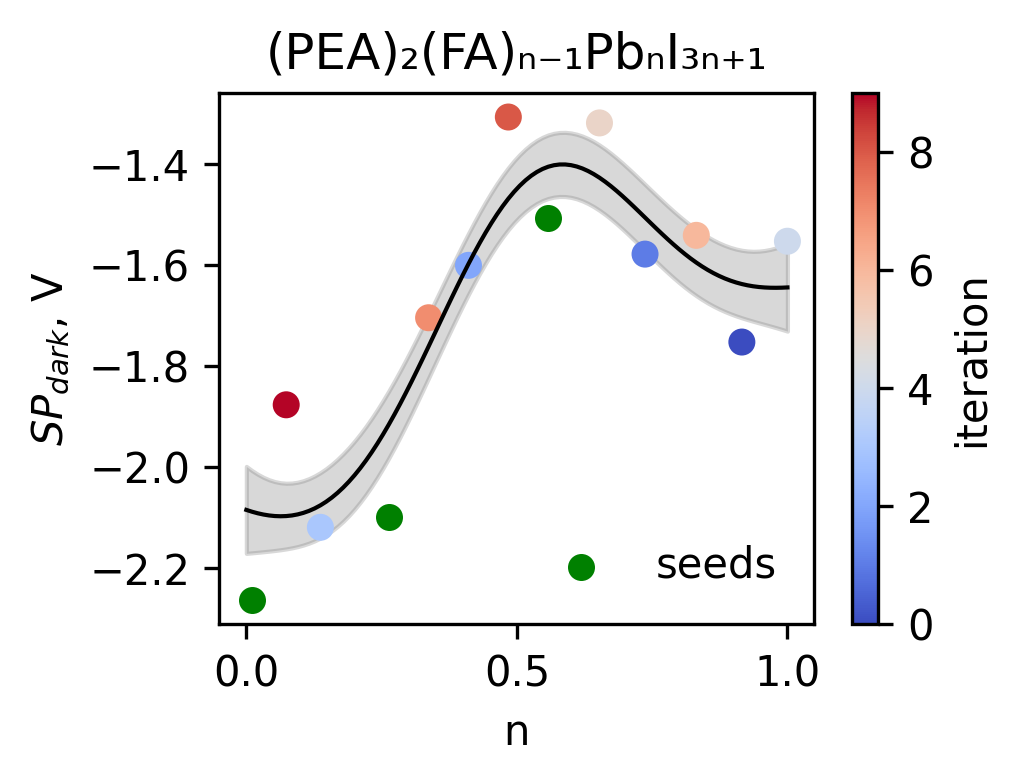

In [ ]:
fig = plt.figure(figsize=(3.2, 2.3), dpi=300)


plt.plot(X, mean, c='k', lw=1)
plt.fill_between(X.flatten(), mean-std, mean+std, alpha=0.3, color='gray')
plt.scatter(X_train.flatten()[:3], sp_dark[:3], s=30, color='green', label='seeds')
im = plt.scatter(X_train.flatten()[3:], sp_dark[3:], s=30, c=np.arange(len(y_train[3:])), cmap='coolwarm')
plt.colorbar(label='iteration')

plt.xlabel('n')
plt.ylabel(r'$SP_{dark}$, V')
plt.legend(frameon=False)

plt.title('(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

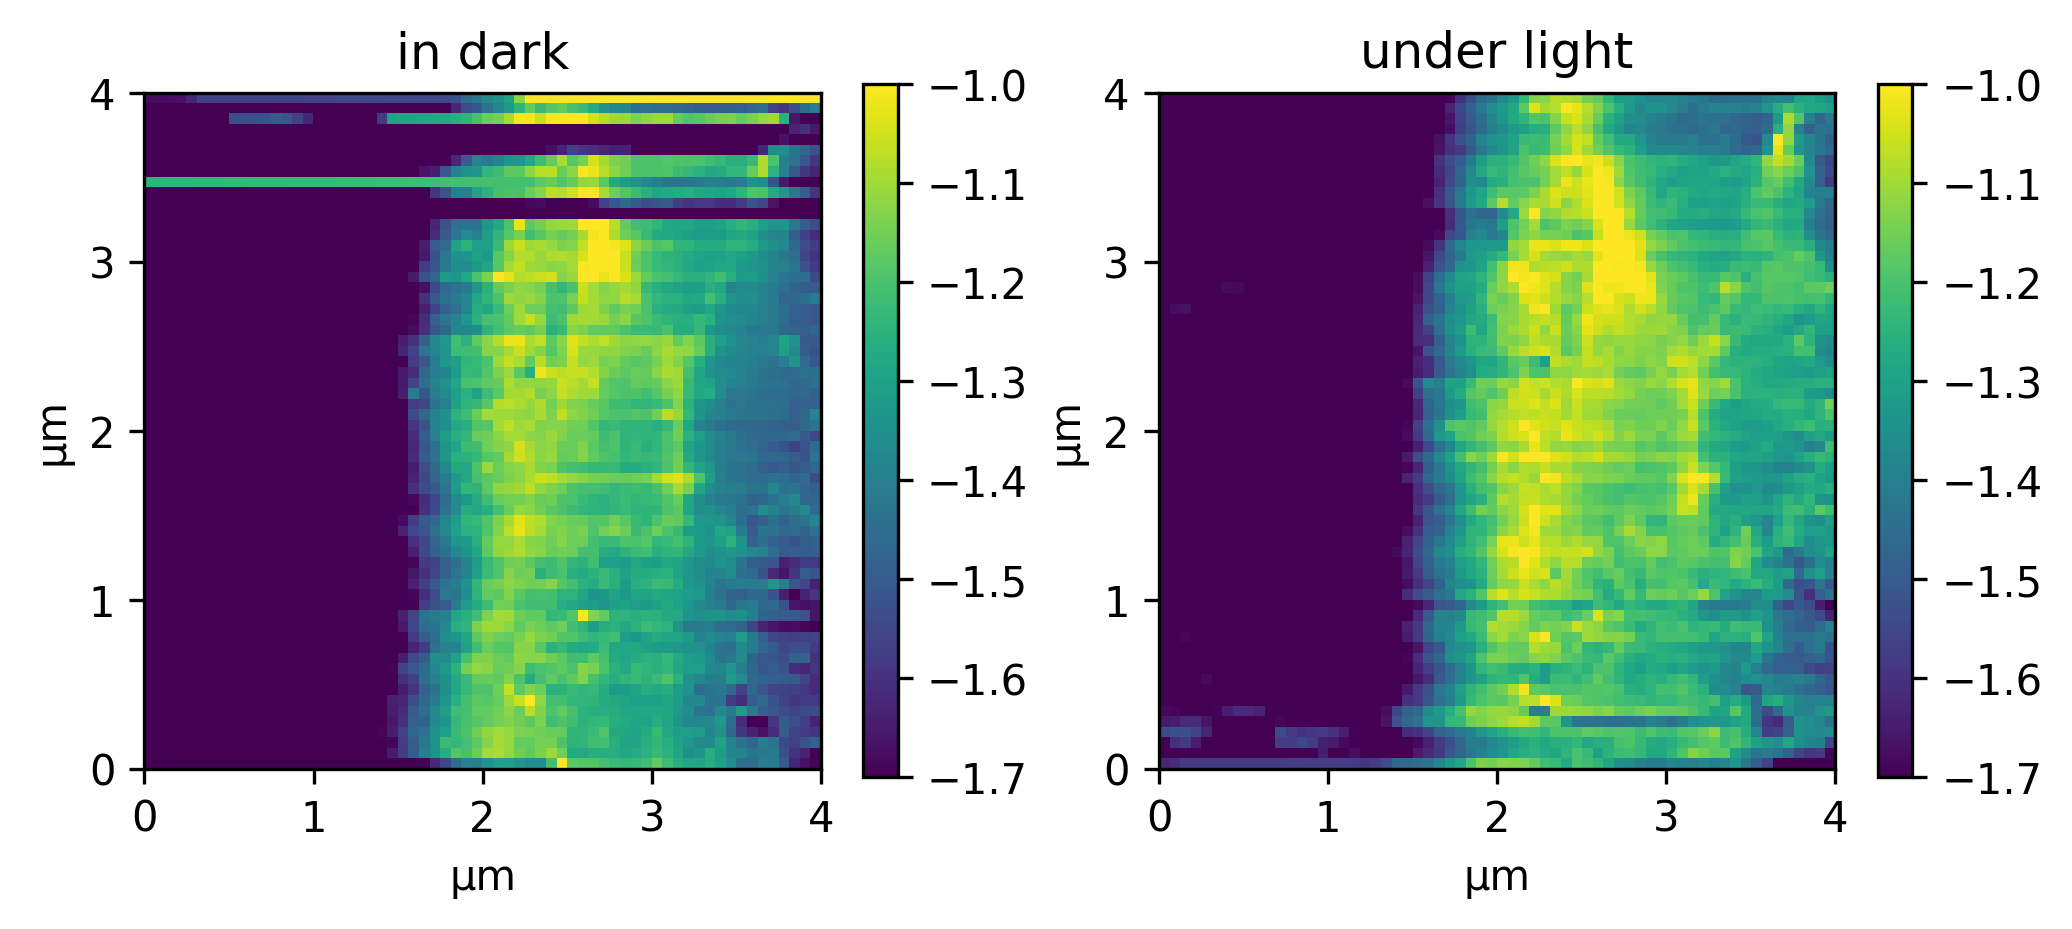

In [ ]:
ii = 7

fig, ax = plt.subplots(1, 2, figsize=(8, 3), dpi=300)

im0 = ax[0].imshow(dark_data[ii], extent=(0,4,0,4), origin='lower', vmax=-1, vmin=-1.7)
plt.colorbar(im0)

im1 =ax[1].imshow(light_data[ii], extent=(0,4,0,4), origin='lower', vmax=-1, vmin=-1.7)
plt.colorbar(im1)

ax[0].set_title('in dark')
ax[1].set_title('under light')

for ax_ in ax:
  ax_.set_xticks([0,1,2,3,4])
  ax_.set_yticks([0,1,2,3,4])
  ax_.set_xlabel('µm')
  ax_.set_ylabel('µm')

In [ ]:
from scipy.optimize import curve_fit

def gaussian1(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

Text(0, 0.5, 'Count')

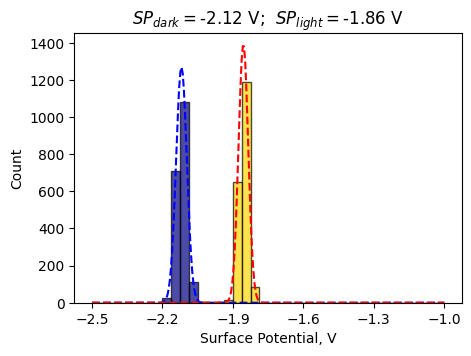

In [ ]:
#select idx
ii = 6

#you can change the range for the hist here, if needed
range_min = -2.5
range_max = -1

fig = plt.figure(figsize=(5,3.5))

counts_d, bin_e_d, _ = plt.hist(dark_data[ii][10:-10, 10:-10].flatten(), color='navy', edgecolor = 'black', alpha=0.7, bins=40, range=(range_min,range_max))

bin_c_d = (bin_e_d[:-1] + bin_e_d[1:]) / 2
opt_d, cov_d = curve_fit(gaussian1, bin_c_d, counts_d)

x_fit = np.linspace(bin_e_d[0], bin_e_d[-1], 300)
y_fit = gaussian1(x_fit, *opt_d)
plt.plot(x_fit, y_fit, '--', color='blue')

counts_l, bin_e_l, _ = plt.hist(light_data[ii][10:-10, 10:-10].flatten(), color='gold', edgecolor = 'black', alpha=0.7, bins=40, range=(range_min,range_max))

bin_c_l = (bin_e_l[:-1] + bin_e_l[1:]) / 2
opt, cov = curve_fit(gaussian1, bin_c_l, counts_l)

x_fit = np.linspace(bin_e_l[0], bin_e_l[-1], 300)
y_fit = gaussian1(x_fit, *opt)
plt.plot(x_fit, y_fit, '--', color='r')

plt.title('$SP_{dark} = $'+f'{round(opt_d[1],2)} V;'+
          '  $SP_{light} = $'+f'{round(opt[1],2)} V'
)

plt.xticks(np.linspace(range_min, range_max, 6))

plt.xlabel('Surface Potential, V')
plt.ylabel('Count')

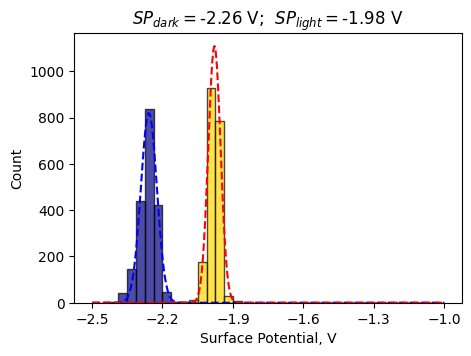

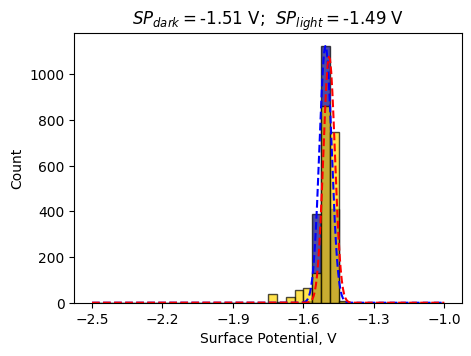

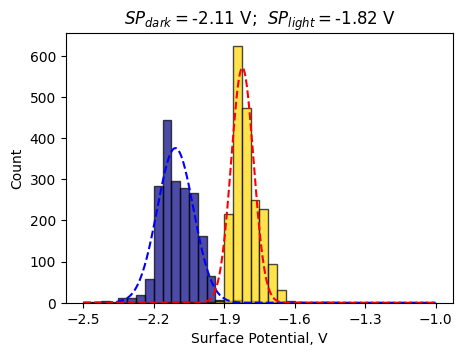

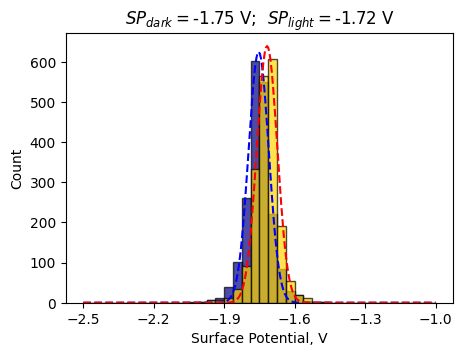

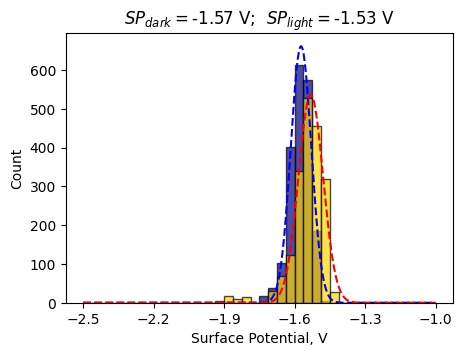

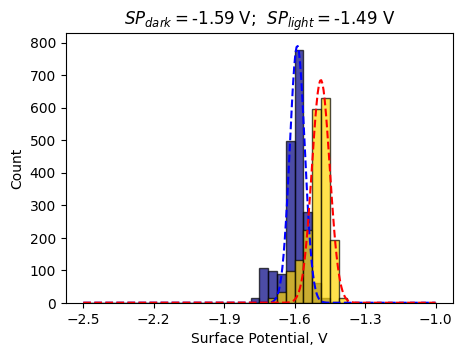

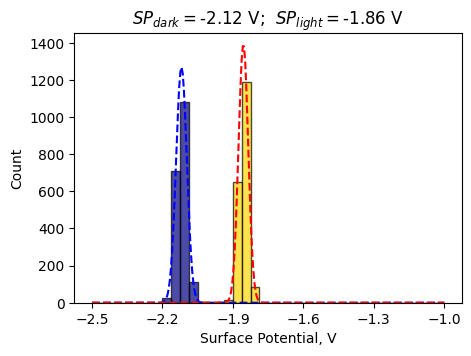

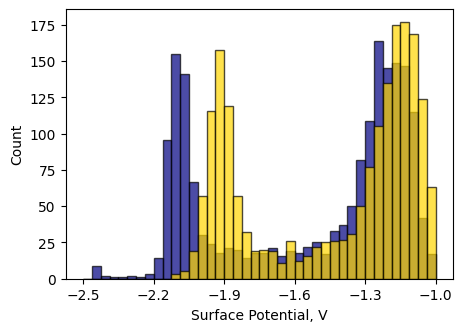

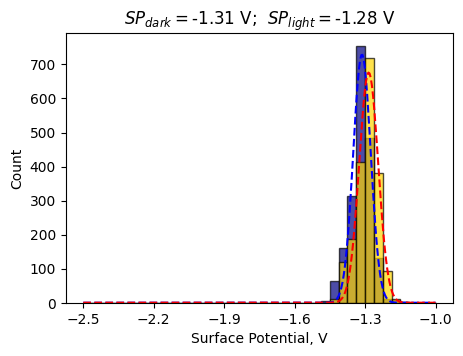

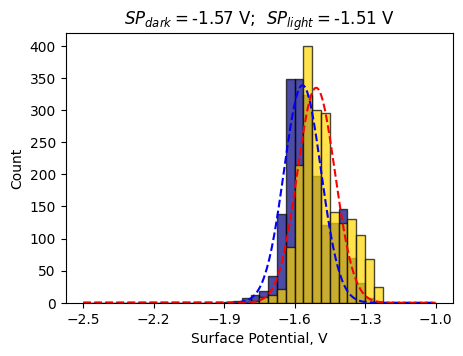

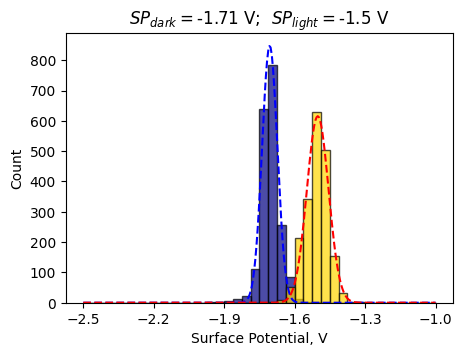

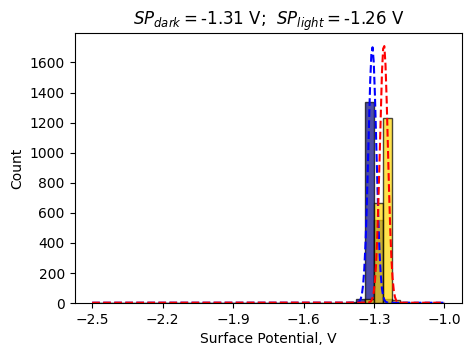

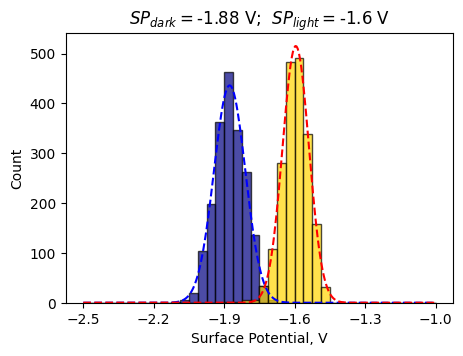

In [ ]:
#select idx
ii = 4

#you can change the range for the hist here, if needed
range_min = -2.5
range_max = -1

for ii in range(len(dark_data)):

  fig = plt.figure(figsize=(5,3.5))

  counts_d, bin_e_d, _ = plt.hist(dark_data[ii][10:-10, 10:-10].flatten(), color='navy', edgecolor = 'black', alpha=0.7, bins=40, range=(range_min,range_max))
  counts_l, bin_e_l, _ = plt.hist(light_data[ii][10:-10, 10:-10].flatten(), color='gold', edgecolor = 'black', alpha=0.7, bins=40, range=(range_min,range_max))



  try:
    bin_c_d = (bin_e_d[:-1] + bin_e_d[1:]) / 2
    opt_d, cov_d = curve_fit(gaussian1, bin_c_d, counts_d)

    x_fit = np.linspace(bin_e_d[0], bin_e_d[-1], 300)
    y_fit = gaussian1(x_fit, *opt_d)
    plt.plot(x_fit, y_fit, '--', color='blue')

    bin_c_l = (bin_e_l[:-1] + bin_e_l[1:]) / 2
    opt, cov = curve_fit(gaussian1, bin_c_l, counts_l)

    x_fit = np.linspace(bin_e_l[0], bin_e_l[-1], 300)
    y_fit = gaussian1(x_fit, *opt)
    plt.plot(x_fit, y_fit, '--', color='r')


    plt.title('$SP_{dark} = $'+f'{round(opt_d[1],2)} V;'+
              '  $SP_{light} = $'+f'{round(opt[1],2)} V'
    )
  except:
    pass

  plt.xticks(np.linspace(range_min, range_max, 6))

  plt.xlabel('Surface Potential, V')
  plt.ylabel('Count')

In [ ]:
def ff(T2, T3, N):
  return (N*T2 + T3)/(N*(T2+T3))

def Sn(T1, T2, T3, N):
  beta = ff(T2, T3, N)
  dt = T2/T1
  return (1+beta*N*dt)/(N*(1+dt))

In [ ]:
t1 = 30
t2 = 0.1
t3 = 5
N = 10

print(Sn(t1, t2, t3, N))

0.10005862810240373


#Experiment 2 ()

In [ ]:
#experimental data 1
!gdown https://drive.google.com/file/d/1bspjmy5KEKv3AbxiRfh4zbn55y371No7/view?usp=sharing --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1bspjmy5KEKv3AbxiRfh4zbn55y371No7
To: /content/PEA_FAPI_3.zip
100% 18.5M/18.5M [00:00<00:00, 48.6MB/s]


In [ ]:
!unzip /content/PEA_FAPI_3.zip

Archive:  /content/PEA_FAPI_3.zip
   creating: PEA_FAPI_3/
  inflating: __MACOSX/._PEA_FAPI_3   
  inflating: PEA_FAPI_3/SKPM_0055.ibw  
  inflating: __MACOSX/PEA_FAPI_3/._SKPM_0055.ibw  
  inflating: PEA_FAPI_3/SKPM_0041.ibw  
  inflating: __MACOSX/PEA_FAPI_3/._SKPM_0041.ibw  
  inflating: PEA_FAPI_3/SKPM_0040.ibw  
  inflating: __MACOSX/PEA_FAPI_3/._SKPM_0040.ibw  
  inflating: PEA_FAPI_3/SKPM_0054.ibw  
  inflating: __MACOSX/PEA_FAPI_3/._SKPM_0054.ibw  
  inflating: PEA_FAPI_3/SKPM_0042.ibw  
  inflating: __MACOSX/PEA_FAPI_3/._SKPM_0042.ibw  
  inflating: PEA_FAPI_3/SKPM_0056.ibw  
  inflating: __MACOSX/PEA_FAPI_3/._SKPM_0056.ibw  
  inflating: PEA_FAPI_3/SKPM_0043.ibw  
  inflating: __MACOSX/PEA_FAPI_3/._SKPM_0043.ibw  
  inflating: PEA_FAPI_3/20260119_PEA_FAPI_3_0.h5  
  inflating: __MACOSX/PEA_FAPI_3/._20260119_PEA_FAPI_3_0.h5  
  inflating: PEA_FAPI_3/SKPM_0047.ibw  
  inflating: __MACOSX/PEA_FAPI_3/._SKPM_0047.ibw  
  inflating: PEA_FAPI_3/SKPM_0053.ibw  
  inflating: __MACOSX/

In [ ]:
file_h5 = r"/content/PEA_FAPI_3/20260119_PEA_FAPI_3_0.h5"

In [ ]:
res_dict = load_hdf5_to_dict(file_h5)

In [ ]:
dark_files = res_dict['dark_fn']
light_files = res_dict['light_fn']

X_train = res_dict['X_train']
X_train_int = (X_train*95).astype(int)
y_train = res_dict['y_train']
X = res_dict['X']

dark_data = res_dict['dark_data']
light_data = res_dict['light_data']
light_files = res_dict['light_fn']
idx = res_dict['idx']

In [ ]:
posterior = gp.posterior(torch.tensor(X))

mean = posterior.mean.detach().numpy().ravel()
std = posterior.variance.sqrt().detach().numpy().ravel()

In [ ]:
gp, kl = make_gp_model(X_train, y_train, interval=(0.1, 1))

posterior = gp.posterior(torch.tensor(X))

mean = posterior.mean.detach().numpy().ravel()
std = posterior.variance.sqrt().detach().numpy().ravel()

Text(0.5, 1.0, '(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

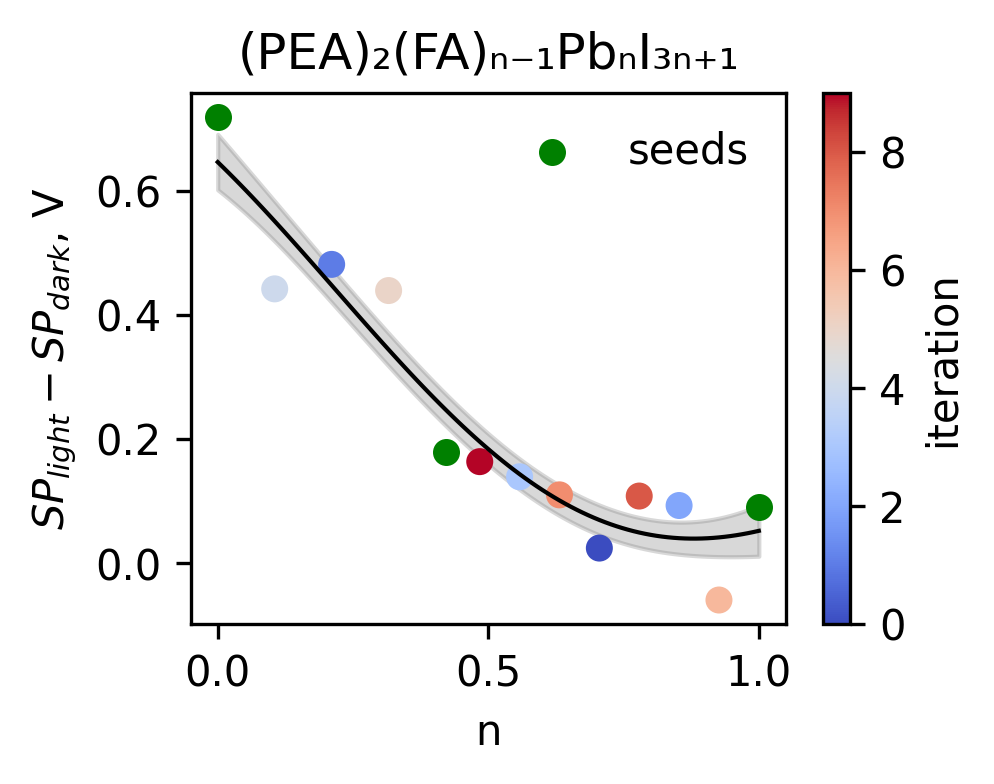

In [ ]:
fig = plt.figure(figsize=(3.2, 2.3), dpi=300)


plt.plot(X, mean, c='k', lw=1)
plt.fill_between(X.flatten(), mean-std, mean+std, alpha=0.3, color='gray')
plt.scatter(X_train.flatten()[:3], y_train[:3], s=30, color='green', label='seeds')
im = plt.scatter(X_train.flatten()[3:], y_train[3:], s=30, c=np.arange(len(y_train[3:])), cmap='coolwarm')
plt.colorbar(label='iteration')

plt.xlabel('n')
plt.ylabel('$SP_{light}-SP_{dark}$, V')
plt.legend(frameon=False)

plt.title('(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

In [ ]:
y_train_cr = light_data[:,10:-10,10:-10].mean((1,2)) - dark_data[:,10:-10,10:-10].mean((1,2))

In [ ]:
gp, kl = make_gp_model(X_train, y_train_cr, interval=(0.1, 1))

In [ ]:
posterior = gp.posterior(torch.tensor(X))

mean = posterior.mean.detach().numpy().ravel()
std = posterior.variance.sqrt().detach().numpy().ravel()

Text(0.5, 1.0, '(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

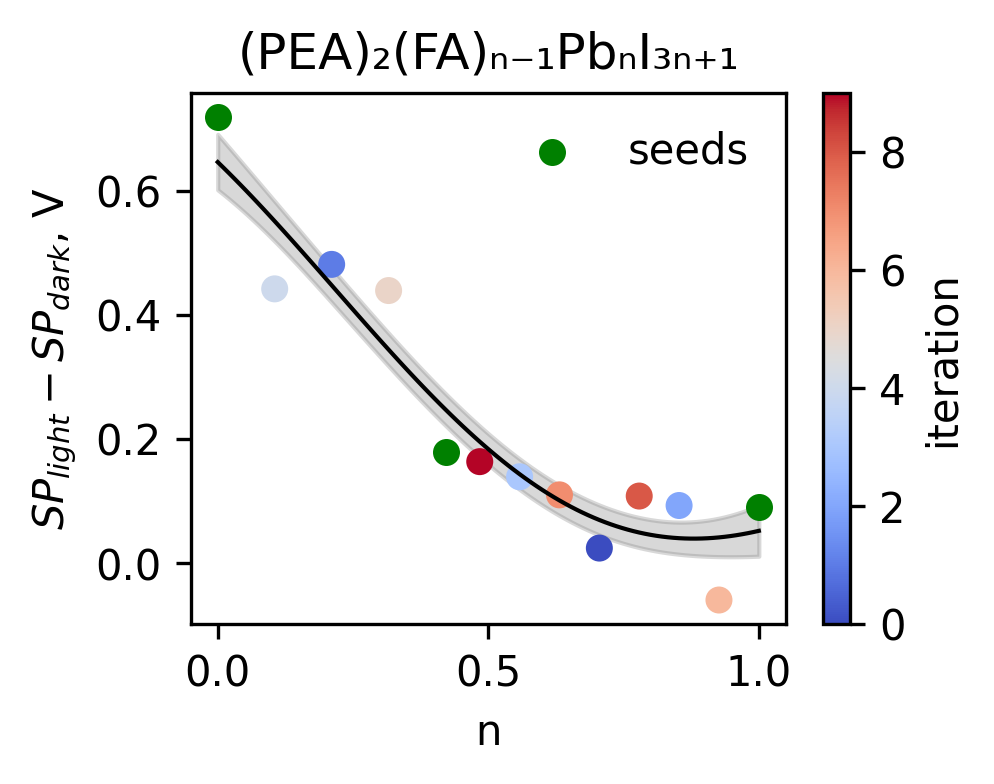

In [ ]:
fig = plt.figure(figsize=(3.2, 2.3), dpi=300)


plt.plot(X, mean, c='k', lw=1)
plt.fill_between(X.flatten(), mean-std, mean+std, alpha=0.3, color='gray')
plt.scatter(X_train.flatten()[:3], y_train_cr[:3], s=30, color='green', label='seeds')
im = plt.scatter(X_train.flatten()[3:], y_train_cr[3:], s=30, c=np.arange(len(y_train[3:])), cmap='coolwarm')
plt.colorbar(label='iteration')

plt.xlabel('n')
plt.ylabel('$SP_{light}-SP_{dark}$, V')
plt.legend(frameon=False)

plt.title('(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

In [ ]:
#SP_dark
sp_dark = dark_data[:,10:-10,10:-10].mean((1,2))
gp1, kl1 = make_gp_model(X_train, sp_dark, interval=(0.1, 1))

In [ ]:
posterior1 = gp1.posterior(torch.tensor(X))

mean1 = posterior1.mean.detach().numpy().ravel()
std1 = posterior1.variance.sqrt().detach().numpy().ravel()

Text(0.5, 1.0, '(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

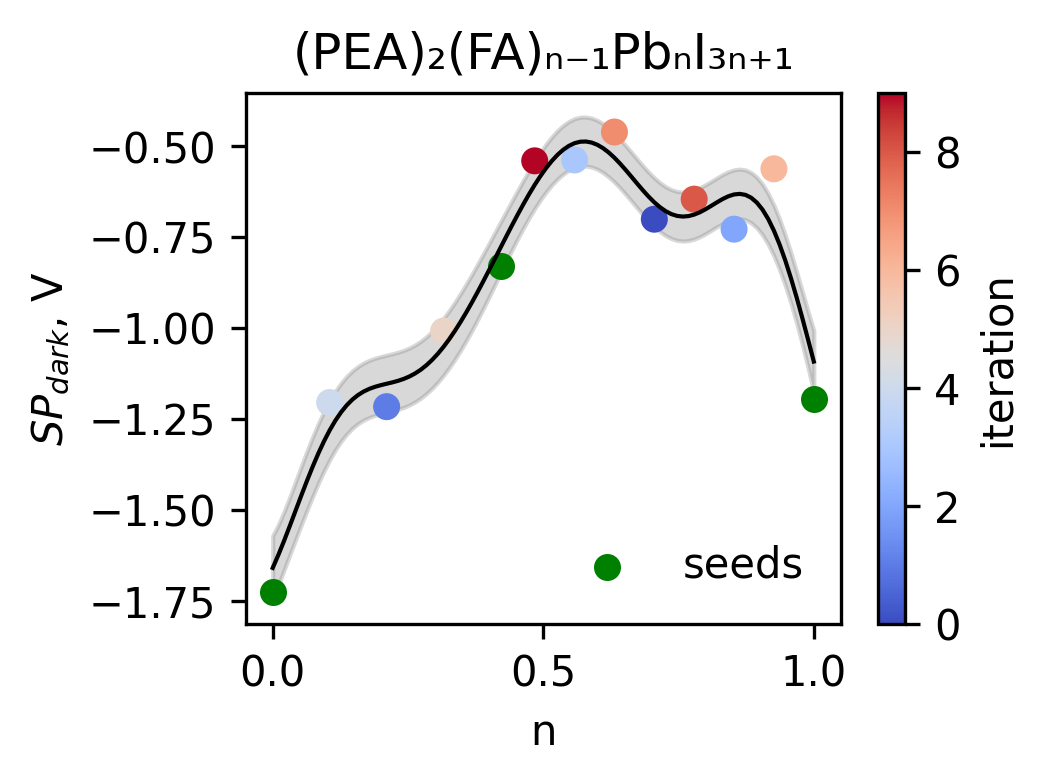

In [ ]:
fig = plt.figure(figsize=(3.2, 2.3), dpi=300)


plt.plot(X, mean1, c='k', lw=1)
plt.fill_between(X.flatten(), mean1-std1, mean1+std1, alpha=0.3, color='gray')
plt.scatter(X_train.flatten()[:3], sp_dark[:3], s=30, color='green', label='seeds')
im = plt.scatter(X_train.flatten()[3:], sp_dark[3:], s=30, c=np.arange(len(y_train[3:])), cmap='coolwarm')
plt.colorbar(label='iteration')

plt.xlabel('n')
plt.ylabel(r'$SP_{dark}$, V')
plt.legend(frameon=False)

plt.title('(PEA)₂(FA)ₙ₋₁PbₙI₃ₙ₊₁')

In [ ]:
from scipy.optimize import curve_fit

def gaussian1(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

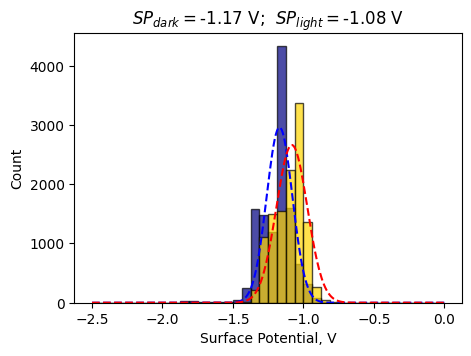

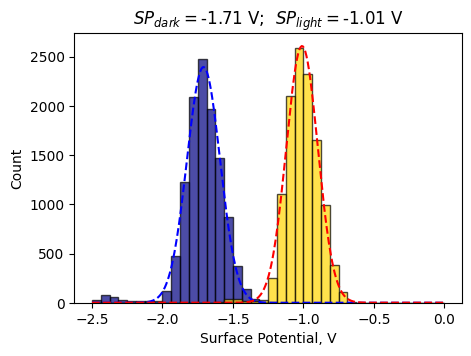

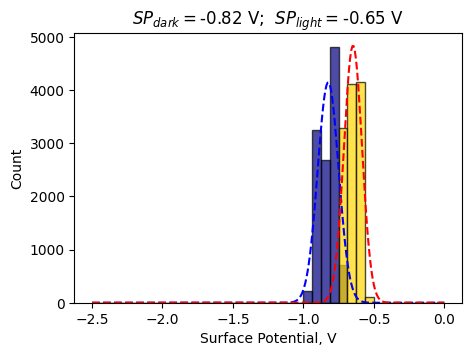

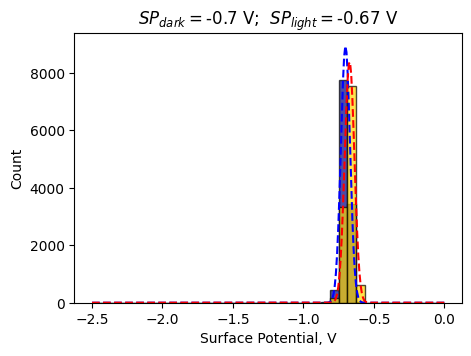

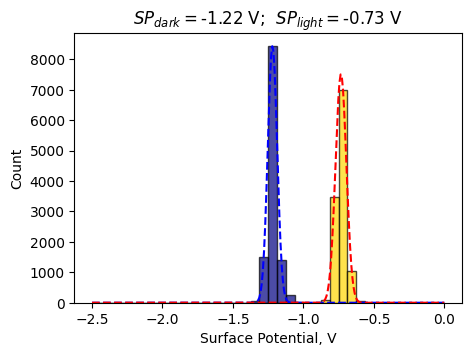

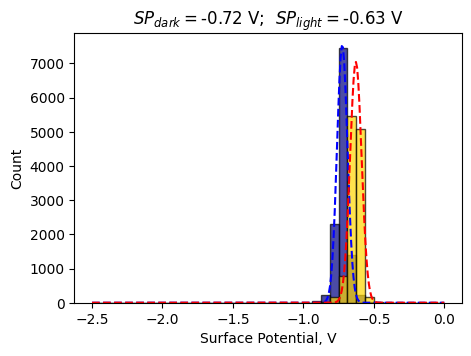

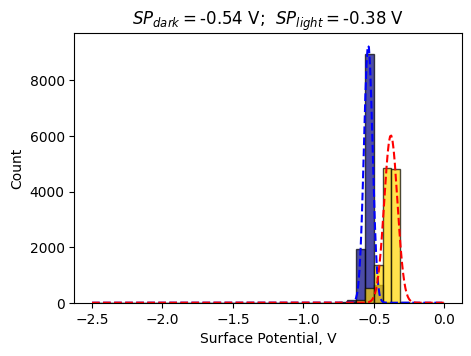

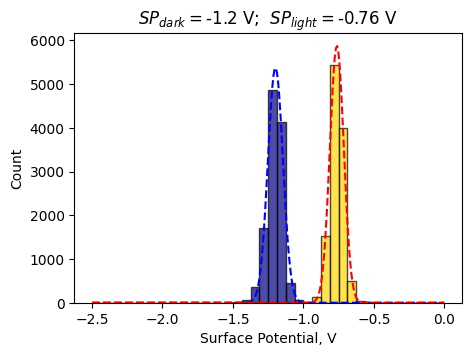

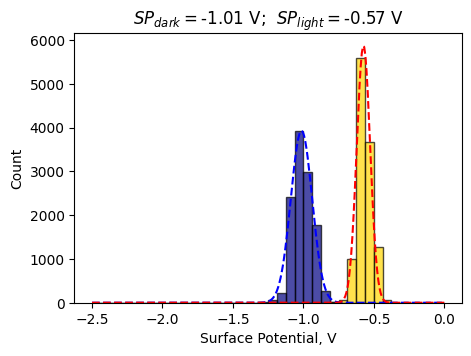

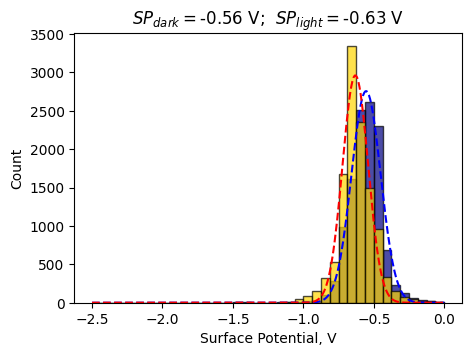

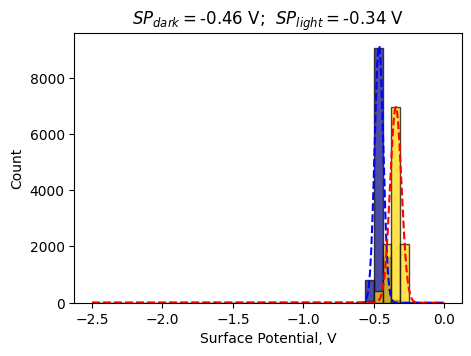

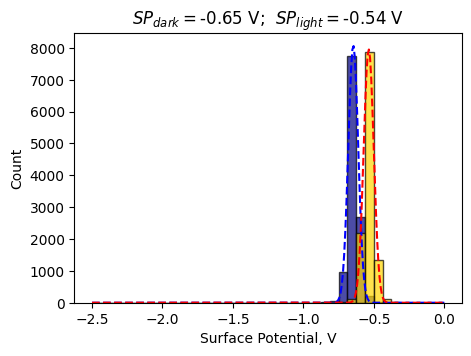

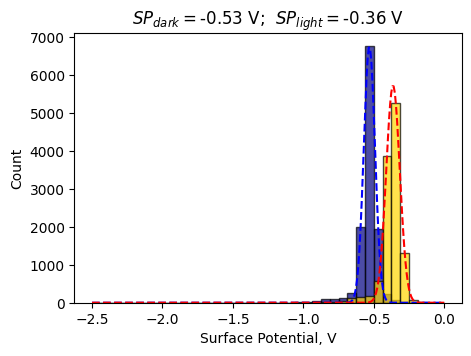

In [ ]:
#select idx
ii = 4

#you can change the range for the hist here, if needed
range_min = -2.5
range_max = -0

for ii in range(len(dark_data)):

  fig = plt.figure(figsize=(5,3.5))

  counts_d, bin_e_d, _ = plt.hist(dark_data[ii][10:-10, 10:-10].flatten(), color='navy', edgecolor = 'black', alpha=0.7, bins=40, range=(range_min,range_max))
  counts_l, bin_e_l, _ = plt.hist(light_data[ii][10:-10, 10:-10].flatten(), color='gold', edgecolor = 'black', alpha=0.7, bins=40, range=(range_min,range_max))



  try:
    bin_c_d = (bin_e_d[:-1] + bin_e_d[1:]) / 2
    opt_d, cov_d = curve_fit(gaussian1, bin_c_d, counts_d)

    x_fit = np.linspace(bin_e_d[0], bin_e_d[-1], 300)
    y_fit = gaussian1(x_fit, *opt_d)
    plt.plot(x_fit, y_fit, '--', color='blue')

    bin_c_l = (bin_e_l[:-1] + bin_e_l[1:]) / 2
    opt, cov = curve_fit(gaussian1, bin_c_l, counts_l)

    x_fit = np.linspace(bin_e_l[0], bin_e_l[-1], 300)
    y_fit = gaussian1(x_fit, *opt)
    plt.plot(x_fit, y_fit, '--', color='r')


    plt.title('$SP_{dark} = $'+f'{round(opt_d[1],2)} V;'+
              '  $SP_{light} = $'+f'{round(opt[1],2)} V'
    )
  except:
    pass

  plt.xticks(np.linspace(range_min, range_max, 6))

  plt.xlabel('Surface Potential, V')
  plt.ylabel('Count')

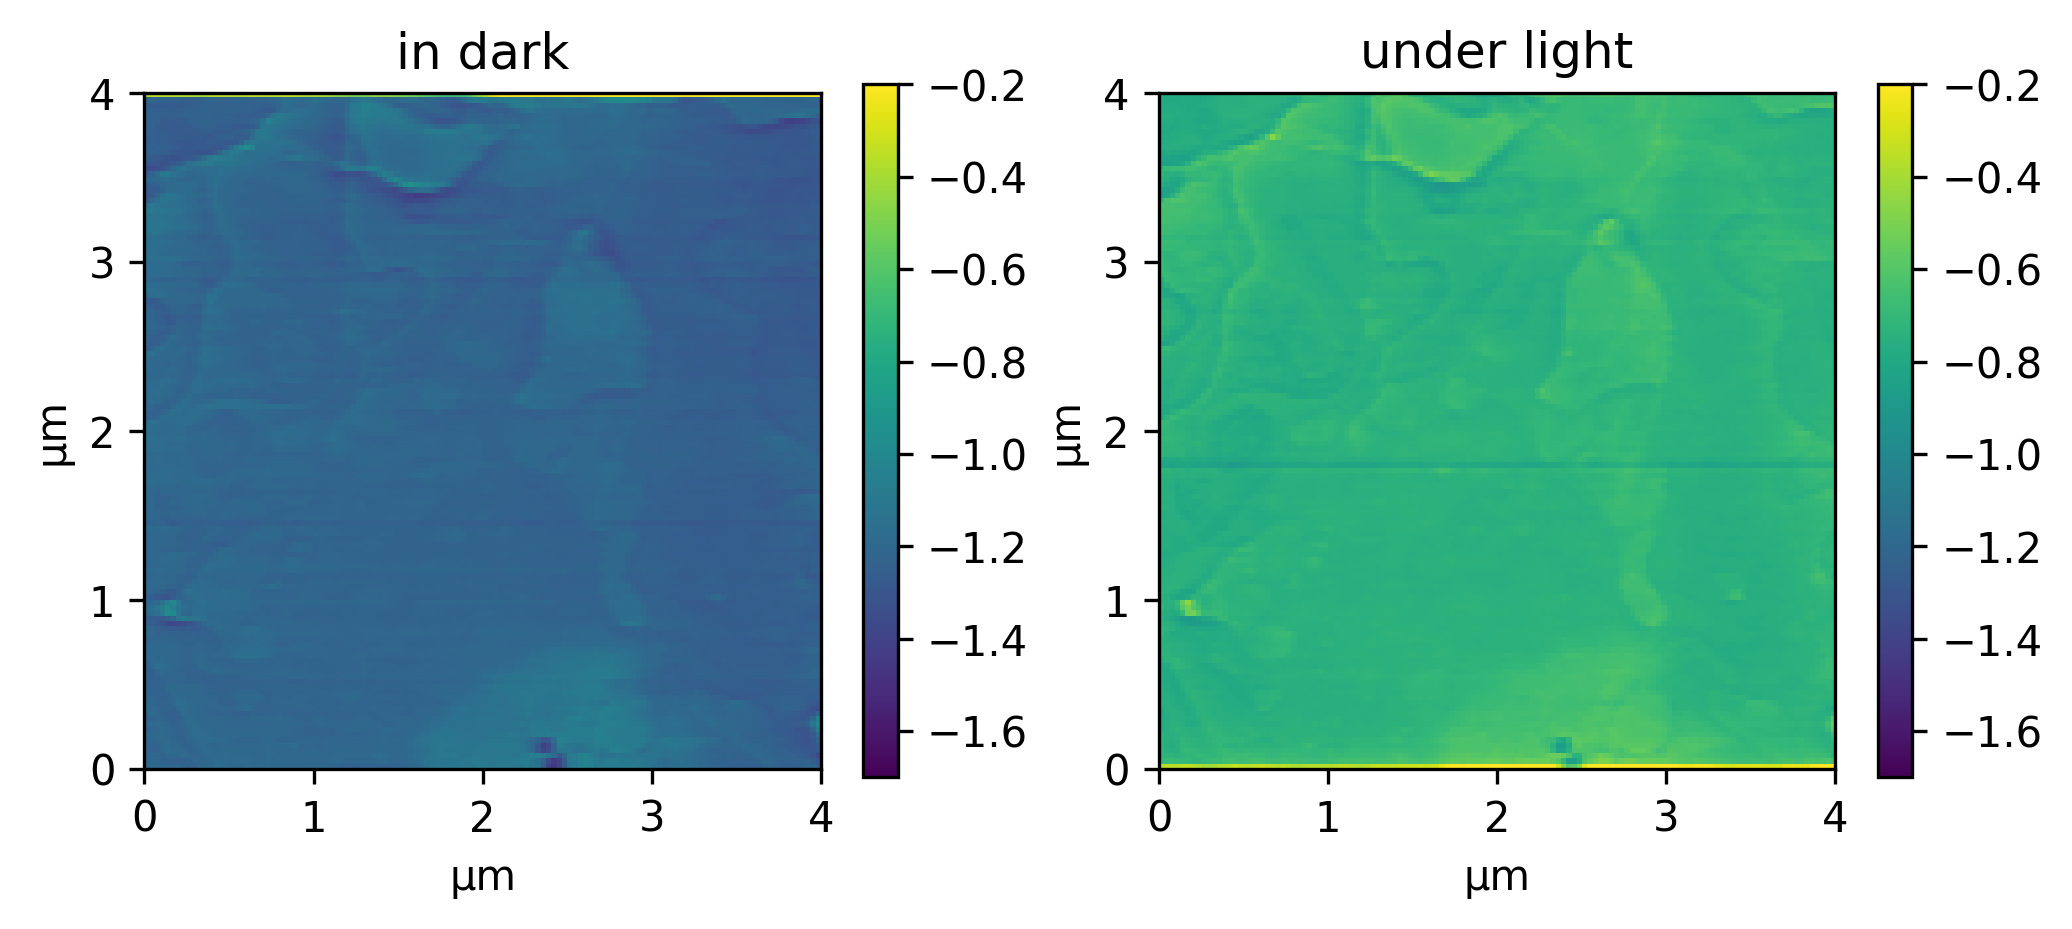

In [ ]:
ii = 4

fig, ax = plt.subplots(1, 2, figsize=(8, 3), dpi=300)

im0 = ax[0].imshow(dark_data[ii], extent=(0,4,0,4), origin='lower', vmax=-0.2, vmin=-1.7)
plt.colorbar(im0)

im1 =ax[1].imshow(light_data[ii], extent=(0,4,0,4), origin='lower', vmax=-0.2, vmin=-1.7)
plt.colorbar(im1)

ax[0].set_title('in dark')
ax[1].set_title('under light')

for ax_ in ax:
  ax_.set_xticks([0,1,2,3,4])
  ax_.set_yticks([0,1,2,3,4])
  ax_.set_xlabel('µm')
  ax_.set_ylabel('µm')

In [ ]:
#@title uncertainty estimation (sigma of gaussian fits)

# per-droplet uncertainty of SP_dark and dSP defined through the std (sigma)
# of the gaussian fitted to the SP histograms:
#   err(SP_dark) = sigma_dark
#   err(dSP)     = sqrt(sigma_dark**2 + sigma_light**2)   (error propagation)
# uses the currently loaded dark_data / light_data

crop = 10
range_min = -2.5
range_max = -0
bins = 40


def fit_mu_sigma(vals, range_min, range_max, bins=40):
    counts, bin_e = np.histogram(vals, bins=bins, range=(range_min, range_max))
    bin_c = (bin_e[:-1] + bin_e[1:]) / 2

    try:
        opt, cov = curve_fit(
            gaussian1,
            bin_c,
            counts,
            p0=[counts.max(), np.mean(vals), np.std(vals)]
        )
        return opt[1], abs(opt[2])

    except:
        # fallback: sample statistics if the fit fails
        return np.mean(vals), np.std(vals)


mu_dark = np.zeros(len(dark_data))
mu_light = np.zeros(len(light_data))
sigma_dark = np.zeros(len(dark_data))
sigma_light = np.zeros(len(light_data))

for ii in range(len(dark_data)):
    dark_vals = dark_data[ii][crop:-crop, crop:-crop].flatten()
    light_vals = light_data[ii][crop:-crop, crop:-crop].flatten()

    mu_dark[ii], sigma_dark[ii] = fit_mu_sigma(dark_vals, range_min, range_max, bins)
    mu_light[ii], sigma_light[ii] = fit_mu_sigma(light_vals, range_min, range_max, bins)

err_sp_dark = sigma_dark
err_dsp = np.sqrt(sigma_dark**2 + sigma_light**2)

print(' ii |     n | SP_dark, V | sigma_d, V | dSP, V | err_dSP, V')
print('-' * 62)
for ii in range(len(dark_data)):
    print(f' {ii:2d} | {X_train.flatten()[ii]:.3f} | '
          f'{mu_dark[ii]:10.3f} | {sigma_dark[ii]:10.3f} | '
          f'{mu_light[ii] - mu_dark[ii]:6.3f} | {err_dsp[ii]:10.3f}')


 ii |     n | SP_dark, V | sigma_d, V | dSP, V | err_dSP, V
--------------------------------------------------------------
  0 | 1.000 |     -1.169 |      0.091 |  0.087 |      0.143
  1 | 0.000 |     -1.709 |      0.117 |  0.699 |      0.162
  2 | 0.421 |     -0.824 |      0.074 |  0.176 |      0.098
  3 | 0.705 |     -0.701 |      0.033 |  0.029 |      0.047
  4 | 0.211 |     -1.219 |      0.033 |  0.486 |      0.051
  5 | 0.853 |     -0.724 |      0.037 |  0.096 |      0.055
  6 | 0.558 |     -0.540 |      0.031 |  0.160 |      0.056
  7 | 0.105 |     -1.198 |      0.053 |  0.436 |      0.073
  8 | 0.316 |     -1.013 |      0.075 |  0.440 |      0.089
  9 | 0.926 |     -0.555 |      0.103 | -0.076 |      0.137
 10 | 0.632 |     -0.463 |      0.031 |  0.120 |      0.051
 11 | 0.779 |     -0.646 |      0.035 |  0.110 |      0.050
 12 | 0.484 |     -0.532 |      0.040 |  0.168 |      0.063


/tmp/ipykernel_1531/1239596031.py:357: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


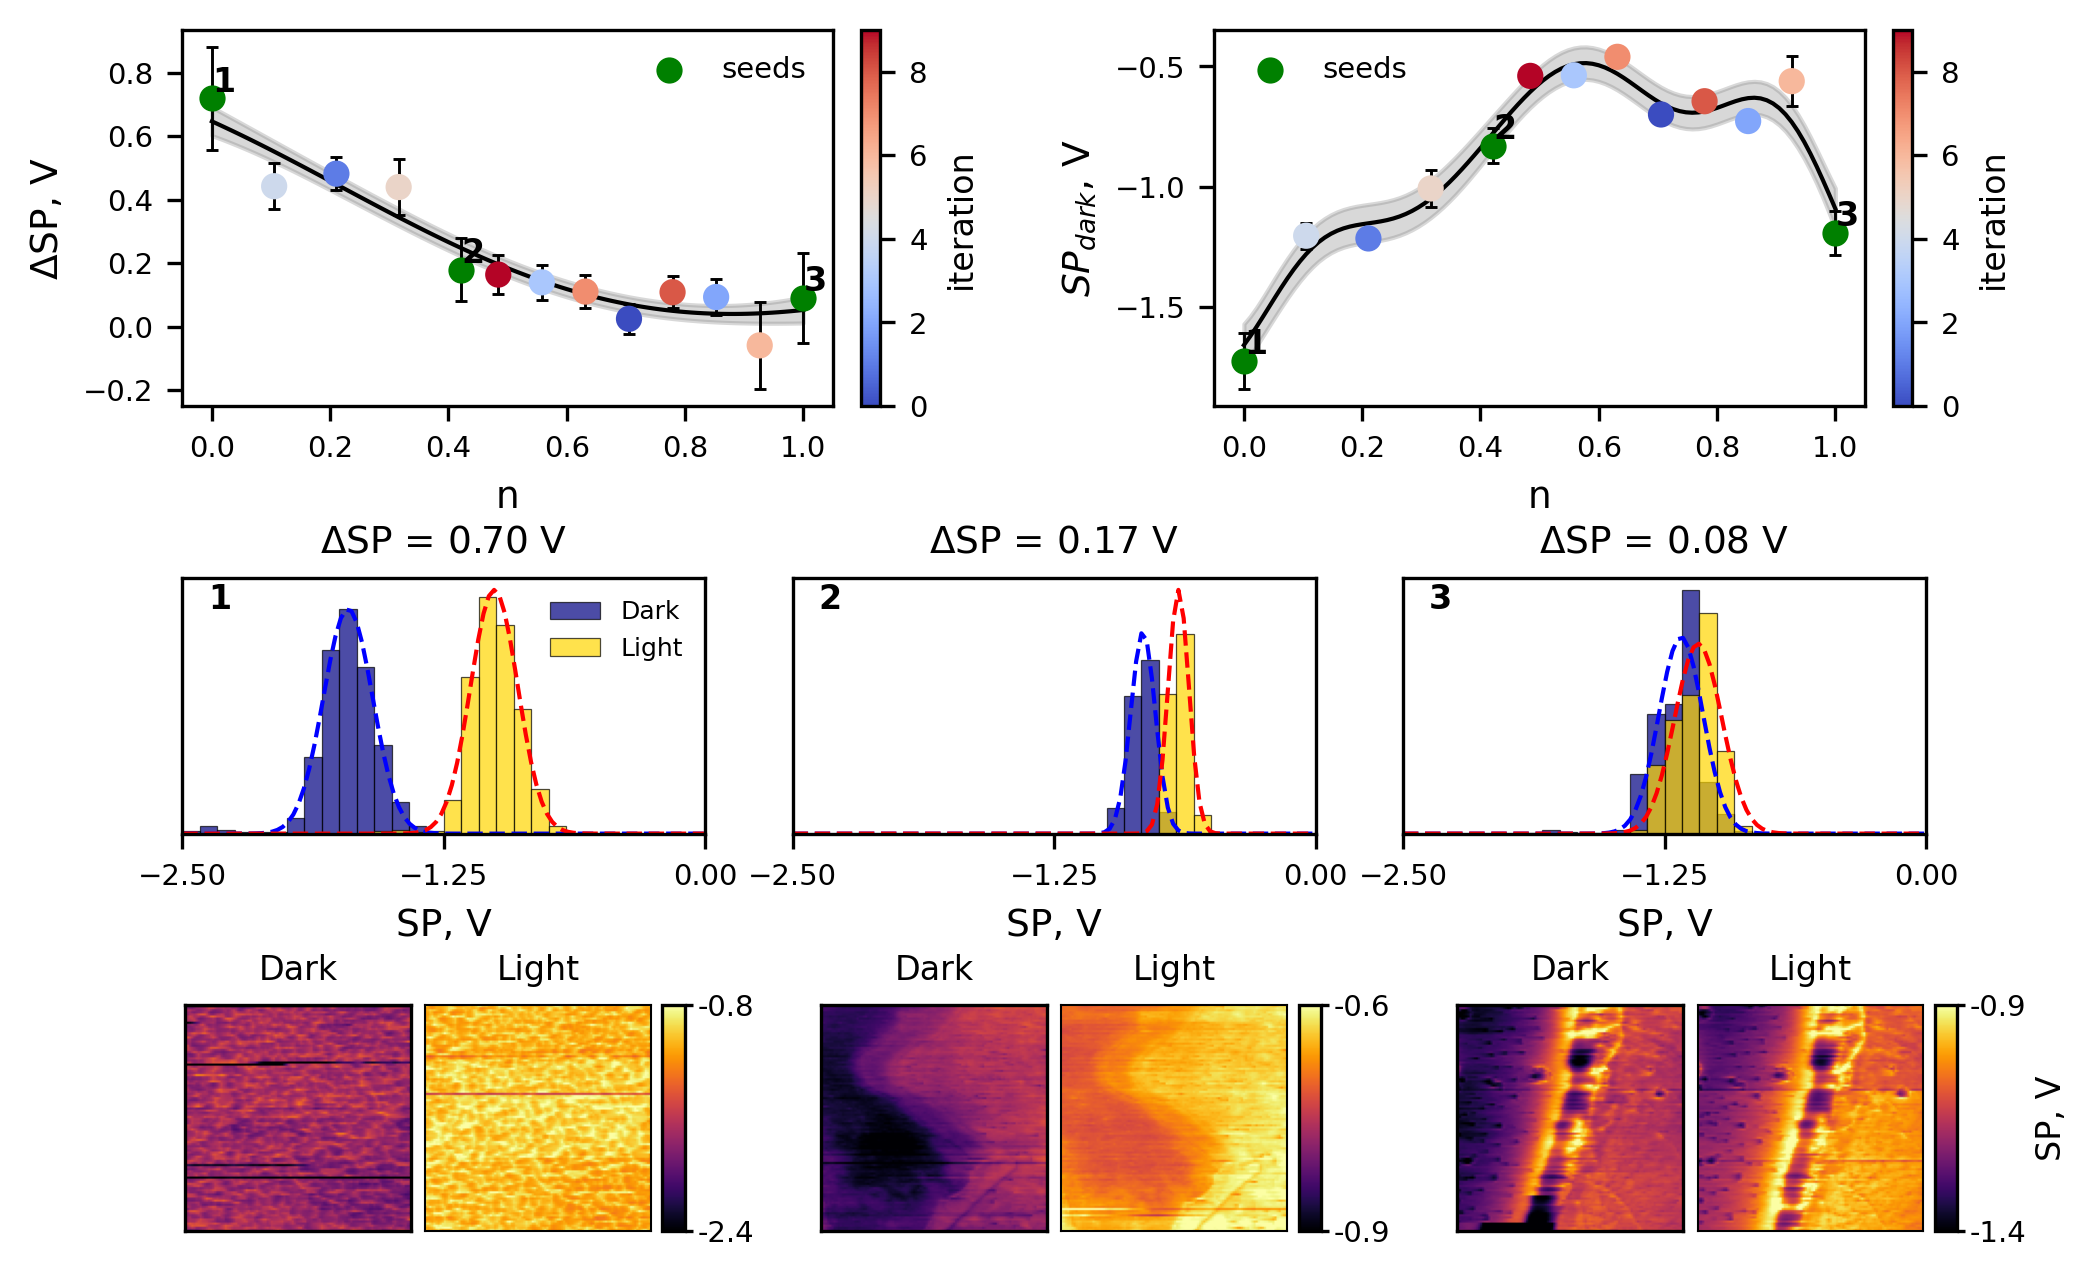

In [ ]:
#@title figure for the draft

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FormatStrFormatter

# -----------------------------
# helper
# -----------------------------
def gaussian1(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


def plot_gp_1d(ax, X, mean, std, X_train, y_train_plot, ylabel, yerr=None):
    x = X.flatten()

    ax.plot(x, mean, c='k', lw=1)
    ax.fill_between(x, mean - std, mean + std, alpha=0.3, color='gray')

    # errorbars (sigma of the gaussian fits)
    if yerr is not None:
        ax.errorbar(
            X_train.flatten(),
            y_train_plot,
            yerr=yerr,
            fmt='none',
            ecolor='k',
            elinewidth=0.7,
            capsize=1.5,
            capthick=0.7,
            zorder=2
        )

    ax.scatter(
        X_train.flatten()[:3],
        y_train_plot[:3],
        s=28,
        color='green',
        label='seeds',
        zorder=3
    )

    im = ax.scatter(
        X_train.flatten()[3:],
        y_train_plot[3:],
        s=28,
        c=np.arange(len(y_train_plot[3:])),
        cmap='coolwarm',
        zorder=3
    )

    ax.set_xlabel('n', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.legend(frameon=False, fontsize=7)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('iteration', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    return im


# -----------------------------
# choose 3 members to show
# -----------------------------
idx_list = [1, 2, 0]   # change to the 3 compositions/members you want

# histogram range
range_min = -2.5
range_max = -0

# scan crop
crop = 10

# -----------------------------
# figure layout
# -----------------------------
fig = plt.figure(figsize=(7.5, 5.2), dpi=300)

gs = fig.add_gridspec(
    3, 6,
    height_ratios=[1.25, 0.85, 0.75],
    wspace=.4,
    hspace=0.6
)

# first row: two large GP plots
# first row with larger spacing between two big plots
gs_top = gs[0, :].subgridspec(
    1, 2,
    wspace=.45   # increase this value if you need more space
)

ax_gp1 = fig.add_subplot(gs_top[0, 0])
ax_gp2 = fig.add_subplot(gs_top[0, 1])

# second row: three histograms
ax_hist = [
    fig.add_subplot(gs[1, 0:2]),
    fig.add_subplot(gs[1, 2:4]),
    fig.add_subplot(gs[1, 4:6]),
]

# third row: six scans, two below each histogram
# ax_scan = []
# for j in range(3):
#     ax_scan.append([
#         fig.add_subplot(gs[2, 2*j]),
#         fig.add_subplot(gs[2, 2*j + 1])
#     ])
# third row: three scan groups
# large spacing between groups
gs_scans = gs[2, :].subgridspec(
    1, 3,
    wspace=0.35
)

ax_scan = []

for j in range(3):
    # small spacing inside each dark/light pair
    gs_pair = gs_scans[0, j].subgridspec(
        1, 2,
        wspace=0.04
    )

    ax_scan.append([
        fig.add_subplot(gs_pair[0, 0]),
        fig.add_subplot(gs_pair[0, 1])
    ])

# -----------------------------
# first row: binary GP plots
# -----------------------------

# plot 1: photovoltage / SP difference
plot_gp_1d(
    ax_gp1,
    X,
    mean,
    std,
    X_train,
    y_train_cr,
    ylabel=r'$\Delta$SP, V',
    yerr=err_dsp
)

# plot 2: dark SP
# If you have separate GP prediction for dark SP, use mean_dark/std_dark here.
# For now I keep mean/std as in your example.
plot_gp_1d(
    ax_gp2,
    X,
    mean1,
    std1,
    X_train,
    sp_dark,
    ylabel=r'$SP_{dark}$, V',
    yerr=err_sp_dark
)



# mark selected members on both GP plots
for j, ii in enumerate(idx_list, start=1):
    x_pt = X_train.flatten()[ii]

    ax_gp1.text(
        x_pt,
        y_train_cr[ii],
        str(j),
        fontsize=8,
        fontweight='bold',
        ha='left',
        va='bottom'
    )

    ax_gp2.text(
        x_pt,
        sp_dark[ii],
        str(j),
        fontsize=8,
        fontweight='bold',
        ha='left',
        va='bottom'
    )


# -----------------------------
# second row: histograms
# -----------------------------
for k, ii in enumerate(idx_list):
    ax = ax_hist[k]

    dark_vals = dark_data[ii][crop:-crop, crop:-crop].flatten()
    light_vals = light_data[ii][crop:-crop, crop:-crop].flatten()

    # panel number
    ax.text(
        0.05, 0.88, str(k + 1),
        transform=ax.transAxes,
        fontsize=8,
        fontweight='bold'
    )

    # dark histogram
    counts_d, bin_e_d, _ = ax.hist(
        dark_vals,
        color='navy',
        edgecolor='black',
        alpha=0.7,
        bins=30,
        linewidth=0.3,
        range=(range_min, range_max),
        label='Dark'
    )

    # dark fit
    bin_c_d = (bin_e_d[:-1] + bin_e_d[1:]) / 2

    try:
        opt_d, _ = curve_fit(
            gaussian1,
            bin_c_d,
            counts_d,
            p0=[counts_d.max(), np.mean(dark_vals), np.std(dark_vals)]
        )

        x_fit = np.linspace(bin_e_d[0], bin_e_d[-1], 100)
        y_fit_d = gaussian1(x_fit, *opt_d)

        ax.plot(x_fit, y_fit_d, '--', color='blue', lw=1)
        mu_d = opt_d[1]

    except:
        mu_d = np.mean(dark_vals)


    # light histogram
    counts_l, bin_e_l, _ = ax.hist(
        light_vals,
        color='gold',
        edgecolor='black',
        alpha=0.7,
        bins=30,
        linewidth=0.3,
        range=(range_min, range_max),
        label='Light'
    )

    # light fit
    bin_c_l = (bin_e_l[:-1] + bin_e_l[1:]) / 2

    try:
        opt_l, _ = curve_fit(
            gaussian1,
            bin_c_l,
            counts_l,
            p0=[counts_l.max(), np.mean(light_vals), np.std(light_vals)]
        )

        x_fit = np.linspace(bin_e_l[0], bin_e_l[-1], 100)
        y_fit_l = gaussian1(x_fit, *opt_l)

        ax.plot(x_fit, y_fit_l, '--', color='red', lw=1)
        mu_l = opt_l[1]

    except:
        mu_l = np.mean(light_vals)


    ax.set_title(rf'$\Delta$SP = {abs(mu_l - mu_d):.2f} V', fontsize=9)

    ax.set_xlim(range_min, range_max)
    ax.set_xticks(np.linspace(range_min, range_max, 3))
    ax.set_yticks([])
    ax.tick_params(labelsize=7)

    ax.set_xlabel('SP, V', fontsize=9)

    if k == 0:
        ax.legend(frameon=False, fontsize=6)


# -----------------------------
# third row: scans
# -----------------------------
for k, ii in enumerate(idx_list):

    dark_img = dark_data[ii][crop:-crop, crop:-crop]
    light_img = light_data[ii][crop:-crop, crop:-crop]

    # same contrast for dark/light pair
    vmin = np.nanpercentile([dark_img, light_img], 1)
    vmax = np.nanpercentile([dark_img, light_img], 99)

    ax_d, ax_l = ax_scan[k]

    im_d = ax_d.imshow(
        dark_img,
        cmap='inferno',
        vmin=vmin,
        vmax=vmax
    )

    im_l = ax_l.imshow(
        light_img,
        cmap='inferno',
        vmin=vmin,
        vmax=vmax
    )

    ax_d.set_title('Dark', fontsize=8)
    ax_l.set_title('Light', fontsize=8)

    for ax_img in [ax_d, ax_l]:
        ax_img.set_xticks([])
        ax_img.set_yticks([])

    for spine in ax_img.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('black')

    # slim shared colorbar for each dark/light pair
    cax = inset_axes(
        ax_l,
        width="10%",
        height="100%",
        loc='center left',
        bbox_to_anchor=(1.05, 0., 1, 1),
        bbox_transform=ax_l.transAxes,
        borderpad=0
    )

    cbar = plt.colorbar(im_l, cax=cax)

    # only min/max ticks, formatted as 1 decimal
    cbar.set_ticks([vmin, vmax])
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    cbar.ax.tick_params(
        labelsize=7,
        length=2,
        pad=1
    )

    # only one label to avoid visual clutter
    if k == 2:
        cbar.set_label('SP, V', fontsize=8, labelpad=2)



plt.tight_layout()
fig.savefig('photoKPFM_binary.jpg', dpi=300, bbox_inches='tight')
#plt.show()

n_initial = 8
measured grid indices = [ 0 10 20 40 53 67 81 95]
next grid index (mu max) = 30
next composition x = 0.3158
predicted mean = 0.3818
predicted std  = 0.1286


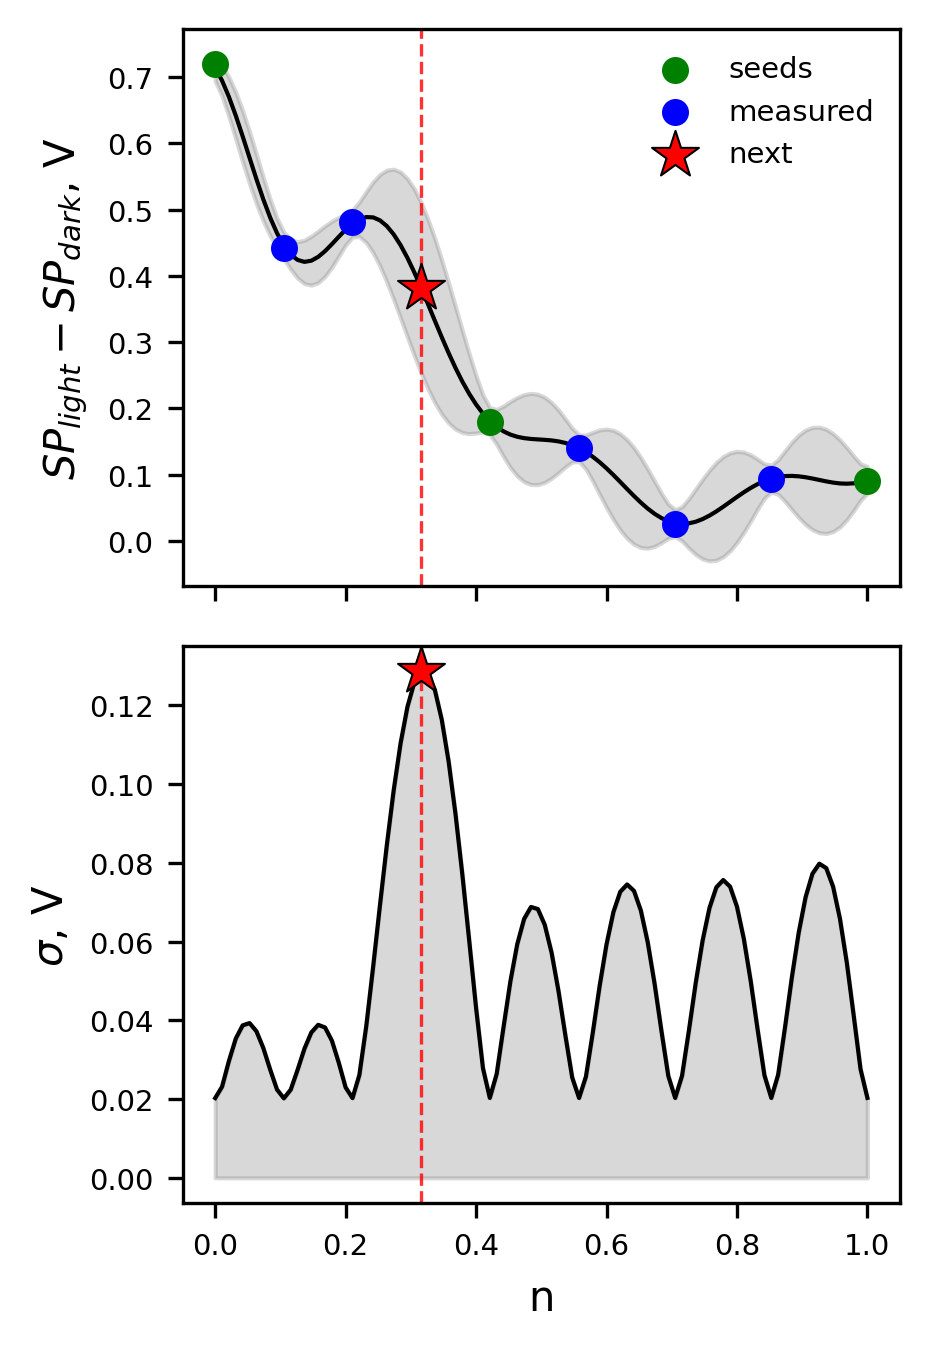

In [ ]:
# ============================================================
# GP mean + uncertainty after n_initial points
# next point selected by maximum posterior mean
# vertical figure, same style as previous plots
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch
import gpytorch

# -----------------------------
# settings
# -----------------------------
n_initial = 8
crop = 10
interval = (0.01, 1)

# choose target
# y_train_plot = y_train                    # if you want the stored target
y_train_plot = light_data[:, crop:-crop, crop:-crop].mean((1, 2)) \
             - dark_data[:, crop:-crop, crop:-crop].mean((1, 2))   # corrected ΔSP

ylabel_top = r'$SP_{light}-SP_{dark}$, V'
ylabel_bottom = r'$\sigma$, V'

# -----------------------------
# prepare data
# -----------------------------
X_all = np.asarray(X).reshape(-1, 1)
X_meas_all = np.asarray(X_train).reshape(-1, 1)
y_all = np.asarray(y_train_plot).ravel()

X_step = X_meas_all[:n_initial]
y_step = y_all[:n_initial]

# -----------------------------
# train GP only on first n_initial points
# -----------------------------
gp_step, kl_step = make_gp_model(X_step, y_step, interval=interval)
gp_step.eval()
gp_step.likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    posterior = gp_step.posterior(torch.tensor(X_all, dtype=torch.double))

mean = posterior.mean.detach().cpu().numpy().ravel()
std = posterior.variance.sqrt().detach().cpu().numpy().ravel()

# -----------------------------
# IMPORTANT:
# remove already measured points using exact grid indices
# -----------------------------
n_grid = len(X_all)

# this matches your notebook logic:
# X_train_int = (X_train * 95).astype(int)
grid_idx_all = np.arange(n_grid)
measured_idx = np.round(X_step.flatten() * (n_grid - 1)).astype(int)
measured_idx = np.clip(measured_idx, 0, n_grid - 1)
measured_idx = np.unique(measured_idx)

candidate_idx = np.setdiff1d(grid_idx_all, measured_idx)

# next point = max posterior mean among unmeasured points
next_idx = candidate_idx[np.argmax(std[candidate_idx])]
next_x = X_all[next_idx, 0]
next_mu = mean[next_idx]
next_std = std[next_idx]

print(f'n_initial = {n_initial}')
print(f'measured grid indices = {measured_idx}')
print(f'next grid index (mu max) = {next_idx}')
print(f'next composition x = {next_x:.4f}')
print(f'predicted mean = {next_mu:.4f}')
print(f'predicted std  = {next_std:.4f}')

# -----------------------------
# plotting
# -----------------------------
fig, ax = plt.subplots(2, 1, figsize=(3.2, 4.6), dpi=300, sharex=True)

x_plot = X_all.flatten()

# ---- top: mean prediction
ax[0].plot(x_plot, mean, c='k', lw=1)
ax[0].fill_between(x_plot, mean - std, mean + std, alpha=0.3, color='gray')

ax[0].scatter(
    X_step.flatten()[:min(3, n_initial)],
    y_step[:min(3, n_initial)],
    s=30,
    color='green',
    label='seeds',
    zorder=3
)

if n_initial > 3:
    im = ax[0].scatter(
        X_step.flatten()[3:],
        y_step[3:],
        s=30,
        c='blue',
        #cmap='coolwarm',
        label='measured',
        zorder=3
    )
    # cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.03)
    # cbar.set_label('iteration', fontsize=8)
    # cbar.ax.tick_params(labelsize=7)

ax[0].scatter(
    next_x,
    next_mu,
    marker='*',
    s=140,
    color='red',
    edgecolor='black',
    linewidth=0.5,
    zorder=5,
    label=r'next'
)

ax[0].axvline(next_x, color='red', ls='--', lw=0.8, alpha=0.8)

ax[0].set_ylabel(ylabel_top)
#ax[0].set_title(f'Prediction after {n_initial} points', fontsize=9)
ax[0].legend(frameon=False, fontsize=7)
ax[0].tick_params(labelsize=7)

# ---- bottom: uncertainty
ax[1].plot(x_plot, std, c='k', lw=1)
ax[1].fill_between(x_plot, 0, std, alpha=0.3, color='gray')

ax[1].scatter(
    next_x,
    next_std,
    marker='*',
    s=140,
    color='red',
    edgecolor='black',
    linewidth=0.5,
    zorder=5
)

ax[1].axvline(next_x, color='red', ls='--', lw=0.8, alpha=0.8)

# # show measured locations on uncertainty panel as small ticks
# for xx in X_step.flatten():
#     ax[1].axvline(xx, color='k', lw=0.4, alpha=0.2)

ax[1].set_xlabel('n')
ax[1].set_ylabel(ylabel_bottom)
ax[1].tick_params(labelsize=7)

plt.tight_layout()
fig.savefig(f'gp_mean_uncertainty_after_{n_initial}_points_vertical.jpeg',
            dpi=300, bbox_inches='tight')
plt.show()